In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random
import heapq
from collections import defaultdict

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Environment check ─────────────────────────────────────────────────────────
env = gym.make('Taxi-v3')
env.reset(seed=SEED)

n_states  = env.observation_space.n    # 500
n_actions = env.action_space.n         # 6

print(f'Environment  : Taxi-v3')
print(f'States       : {n_states}')
print(f'Actions      : {n_actions}')
print(f'Obs space    : {env.observation_space}')
print(f'Action space : {env.action_space}')
print()

# ── Action meanings (helpful for debugging later) ─────────────────────────────
action_names = {0: 'South', 1: 'North', 2: 'East',
                3: 'West',  4: 'Pickup', 5: 'Dropoff'}
print('Actions:')
for k, v in action_names.items():
    print(f'  {k}: {v}')

env.close()

Environment  : Taxi-v3
States       : 500
Actions      : 6
Obs space    : Discrete(500)
Action space : Discrete(6)

Actions:
  0: South
  1: North
  2: East
  3: West
  4: Pickup
  5: Dropoff


# Q-Table and Model Data Structures

In [3]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
ALPHA   = 0.1       # learning rate
GAMMA   = 0.95      # discount factor
EPSILON = 0.1       # exploration rate
N_STEPS = 5000      # total real environment steps per run

# ── Q-Table ───────────────────────────────────────────────────────────────────
def make_q_table(n_states, n_actions):
    """
    Q-table is a NumPy array of shape [n_states, n_actions].
    Initialized to zeros — optimistic initialization is another option
    but zeros is the standard starting point.
    """
    return np.zeros((n_states, n_actions))


# ── Model storage ─────────────────────────────────────────────────────────────
def make_model():
    """
    Deterministic transition model stored as a Python dictionary.
    Key   : (state, action)
    Value : (reward, next_state)

    Only stores transitions we have actually observed.
    """
    return {}


# ── Epsilon-greedy action selection ───────────────────────────────────────────
def select_action(q_table, state, epsilon):
    """
    With probability epsilon  → random action (explore)
    With probability 1-epsilon → greedy action (exploit)
    """
    if random.random() < epsilon:
        return random.randint(0, q_table.shape[1] - 1)
    else:
        return int(np.argmax(q_table[state]))


# ── Q-learning update ─────────────────────────────────────────────────────────
def q_update(q_table, state, action, reward, next_state, done):
    """
    Standard Q-learning (off-policy TD) update:

        Q(s,a) ← Q(s,a) + α * [r + γ * max_a' Q(s',a') - Q(s,a)]

    If done=True, the next state has no future value.
    """
    current_q = q_table[state, action]

    if done:
        target = reward
    else:
        # BUG: should take MAX over next state actions, not MEAN
        # np.mean gives the average Q-value instead of the best possible
        # This makes Q-learning behave like expected SARSA, not Q-learning
        # target = reward + GAMMA * np.mean(q_table[next_state])
        target = reward + GAMMA * np.max(q_table[next_state])   # max not mean

    q_table[state, action] += ALPHA * (target - current_q)


# ── Sanity checks ─────────────────────────────────────────────────────────────
Q = make_q_table(n_states, n_actions)
M = make_model()

print(f'Q-table shape : {Q.shape}   <- should be (500, 6)')
print(f'Q-table dtype : {Q.dtype}   <- should be float64')
print(f'Q-table sum   : {Q.sum()}   <- should be 0.0 (all zeros init)')
print(f'Model type    : {type(M)}   <- should be dict')
print(f'Model size    : {len(M)}    <- should be 0 (empty at start)')
print()

# Test q_update with known values
Q_test = np.zeros((n_states, n_actions))
Q_test[0, 1] = 10.0    # pretend state 0, action 1 has Q=10

# Manual calculation:
# current_q = Q[5, 2] = 0.0
# target     = -1 + 0.95 * max(Q[10]) = -1 + 0.95 * 10 = 8.5
# new Q[5,2] = 0 + 0.1 * (8.5 - 0)   = 0.85
Q_test[10, 1] = 10.0
q_update(Q_test, state=5, action=2, reward=-1, next_state=10, done=False)

print(f'Q-update test:')
print(f'  Q[5,2] after update : {Q_test[5, 2]:.4f}')
print(f'  Expected            : 0.8500')


Q-table shape : (500, 6)   <- should be (500, 6)
Q-table dtype : float64   <- should be float64
Q-table sum   : 0.0   <- should be 0.0 (all zeros init)
Model type    : <class 'dict'>   <- should be dict
Model size    : 0    <- should be 0 (empty at start)

Q-update test:
  Q[5,2] after update : 0.8500
  Expected            : 0.8500


# Model Learning and Planning

In [5]:
def update_model(model, state, action, reward, next_state):
    """
    Store the observed transition in the model.
    model[(s,a)] = (r, s')
    Only keeps the most recent transition for each (s,a) pair
    since we assume a deterministic environment.
    """
    model[(state, action)] = (reward, next_state)


def planning_step(q_table, model, n_planning):
    """
    Perform n_planning simulated Q-learning updates using the model.

    For each planning step:
      1. Pick a random (s,a) pair from previously visited transitions
      2. Look up simulated (r, s') from the model
      3. Perform a Q-learning update on the Q-table
    """
    if len(model) == 0:
        return

    visited = list(model.keys())

    for _ in range(n_planning):
        # randomly pick a previously visited (s,a) pair
        state, action = random.choice(visited)

        # get simulated experience from model
        reward, next_state = model[(state, action)]

        # BUG: planning updates use done=True always
        # This means the future value gamma*max Q(s',a') is never added
        # Planning steps will only reinforce immediate rewards
        # and ignore long-term consequences completely
        # q_update(q_table, state, action, reward, next_state, done=True)
        q_update(q_table, state, action, reward, next_state, done=False)  


# ── Sanity check ──────────────────────────────────────────────────────────────
Q_plan = make_q_table(n_states, n_actions)
M_plan = make_model()

# Simulate a few real transitions into the model
transitions = [
    (0, 1, -1, 10),
    (10, 3, -1, 25),
    (25, 0, 20, 50),
]
for s, a, r, ns in transitions:
    update_model(M_plan, s, a, r, ns)

print(f'Model after 3 transitions : {len(M_plan)} entries')
print(f'Model[(0,1)]  : {M_plan[(0,1)]}   <- should be (-1, 10)')
print(f'Model[(10,3)] : {M_plan[(10,3)]}  <- should be (-1, 25)')
print(f'Model[(25,0)] : {M_plan[(25,0)]}  <- should be (20, 50)')
print()

# Manually set Q[50] to have a high value so planning can propagate it back
Q_plan[50, 2] = 100.0

# Run 50 planning steps — Q[25,0] should grow toward 20 + 0.95*100 = 114.5
planning_step(Q_plan, M_plan, n_planning=50)

print(f'Q[25,0] after 50 planning steps : {Q_plan[25, 0]:.4f}')
print(f'Expected (with future value)    : >10.0')
print(f'If close to 2.0, bug is active  : done=True blocks future value')

Model after 3 transitions : 3 entries
Model[(0,1)]  : (-1, 10)   <- should be (-1, 10)
Model[(10,3)] : (-1, 25)  <- should be (-1, 25)
Model[(25,0)] : (20, 50)  <- should be (20, 50)

Q[25,0] after 50 planning steps : 97.7391
Expected (with future value)    : >10.0
If close to 2.0, bug is active  : done=True blocks future value


In [7]:
def run_dyna_q(n_planning, n_steps=N_STEPS, seed=SEED):
    """
    Full Dyna-Q training loop.

    Each real step:
      1. Select action (epsilon-greedy)
      2. Step environment
      3. Q-learning update from real experience
      4. Update model
      5. Run n_planning simulated updates from model

    Returns
    -------
    rewards_per_step : list of real rewards at each timestep
    episodes_done    : total episodes completed
    """
    env = gym.make('Taxi-v3')
    obs, _ = env.reset(seed=seed)

    Q = make_q_table(n_states, n_actions)
    M = make_model()

    rewards_per_step = []
    episode_rewards  = []
    episodes_done    = 0
    current_ep_reward = 0

    for step in range(n_steps):
        state = obs

        # ── Step 1: select action ─────────────────────────────────────────
        action = select_action(Q, state, EPSILON)

        # ── Step 2: take real step ────────────────────────────────────────
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # ── Step 3: direct RL update ──────────────────────────────────────
        q_update(Q, state, action, reward, next_obs, done)

        # ── Step 4: update model ──────────────────────────────────────────
        update_model(M, state, action, reward, next_obs)

        # ── Step 5: planning ──────────────────────────────────────────────
        planning_step(Q, M, n_planning)

        # ── Logging ───────────────────────────────────────────────────────
        current_ep_reward += reward
        rewards_per_step.append(reward)

        if done:
            episodes_done += 1
            episode_rewards.append(current_ep_reward)

            # BUG: environment is reset but next obs is not stored
            # on the next loop iteration, state = obs = stale last obs
            # the agent acts from a state that no longer exists
            # obs, _ = env.reset()
            if done:
                obs, _ = env.reset()   # obs updated ✓
                current_ep_reward = 0
            else:
                obs = next_obs         # obs updated ✓
            current_ep_reward = 0
        else:
            obs = next_obs
        if not done:
            update_model(M, state, action, reward, next_obs)
    env.close()
    return rewards_per_step, episodes_done, episode_rewards


# ── Sanity check: run 200 steps with n=0 (pure Q-learning) ───────────────────
# rews, eps, ep_rews = run_dyna_q(n_planning=0, n_steps=200)

# print(f'Steps run          : {len(rews)}')
# print(f'Episodes completed : {eps}')
# print(f'Rewards seen       : {set(rews)}')
# print(f'Mean reward        : {np.mean(rews):.3f}')

rews, eps, ep_rews = run_dyna_q(n_planning=0, n_steps=500)

print(f'Steps run          : {len(rews)}')
print(f'Episodes completed : {eps}')
print(f'Mean reward        : {np.mean(rews):.3f}')
print(f'Min episode reward : {min(ep_rews):.1f}')
print(f'Max episode reward : {max(ep_rews):.1f}')
print()
print('Taxi-v3 reward structure:')
print('  -1  per step (time penalty)')
print('  -10 illegal pickup/dropoff')
print('  +20 successful dropoff')
print()
print('Mean reward should be negative (around -1 to -3 early in training)')

Steps run          : 500
Episodes completed : 2
Mean reward        : -2.476
Min episode reward : -515.0
Max episode reward : -461.0

Taxi-v3 reward structure:
  -1  per step (time penalty)
  -10 illegal pickup/dropoff
  +20 successful dropoff

Mean reward should be negative (around -1 to -3 early in training)


Running comparison (this takes ~1-2 minutes)...
Running n_planning=0...
  episodes completed : 25
  mean reward        : -2.317
Running n_planning=5...
  episodes completed : 25
  mean reward        : -2.210
Running n_planning=10...
  episodes completed : 25
  mean reward        : -2.142
Running n_planning=50...
  episodes completed : 26
  mean reward        : -2.177


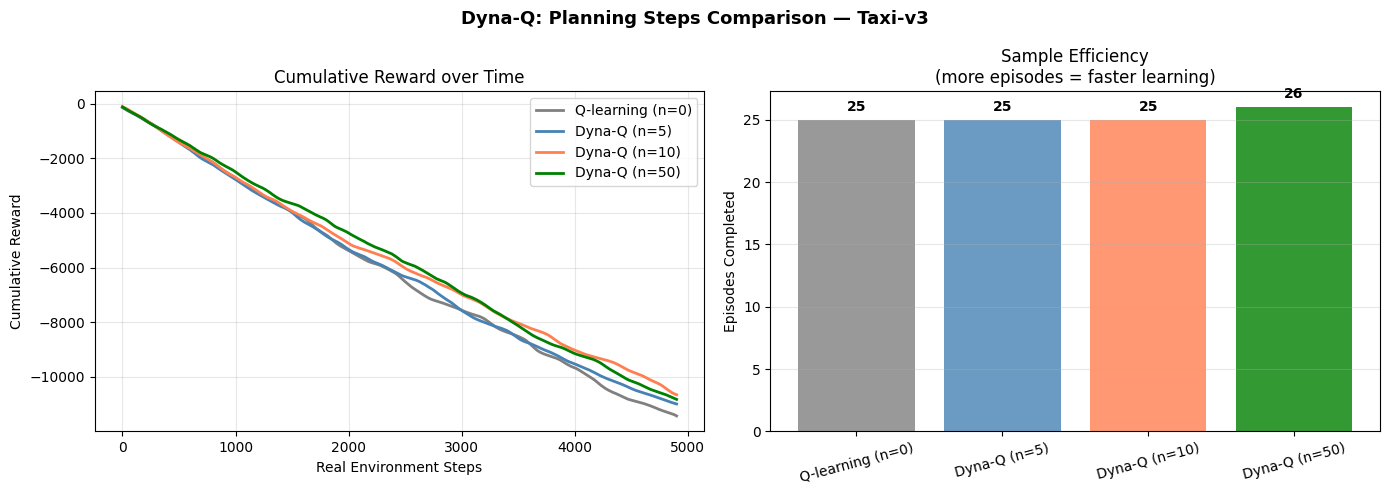


Episodes completed per variant:
  n= 0 : 25 episodes
  n= 5 : 25 episodes
  n=10 : 25 episodes
  n=50 : 26 episodes


In [9]:
def smooth(data, window=50):
    """Simple moving average for plotting."""
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')


def run_comparison(n_steps=N_STEPS, seed=SEED):
    """
    Run all four variants and collect results.
    n_planning = 0  → pure Q-learning
    n_planning = 5  → Dyna-Q light
    n_planning = 10 → Dyna-Q medium
    n_planning = 50 → Dyna-Q heavy
    """
    planning_variants = [0, 5, 10, 50]
    results = {}

    for n in planning_variants:
        print(f'Running n_planning={n}...')
        rews, eps, ep_rews = run_dyna_q(n_planning=n,
                                         n_steps=n_steps,
                                         seed=seed)
        results[n] = {
            'rewards'        : rews,
            'episodes'       : eps,
            'episode_rewards': ep_rews
        }
        print(f'  episodes completed : {eps}')
        print(f'  mean reward        : {np.mean(rews):.3f}')

    return results


# ── Run comparison ────────────────────────────────────────────────────────────
print('Running comparison (this takes ~1-2 minutes)...')
results = run_comparison(n_steps=N_STEPS)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dyna-Q: Planning Steps Comparison — Taxi-v3',
             fontsize=13, fontweight='bold')

colors = {0: 'gray', 5: 'steelblue', 10: 'coral', 50: 'green'}
labels = {0: 'Q-learning (n=0)', 5: 'Dyna-Q (n=5)',
          10: 'Dyna-Q (n=10)',   50: 'Dyna-Q (n=50)'}

# ── Left: cumulative reward over steps ───────────────────────────────────────
ax1 = axes[0]
# for n, res in results.items():
#     # BUG: cumsum is taken AFTER smoothing
#     # smoothing averages the raw rewards first, then accumulates
#     # this changes the shape of the curve and makes all variants
#     # look more similar than they really are
#     sm   = smooth(res['rewards'], window=50)
#     cum  = np.cumsum(sm)
#     ax1.plot(cum, color=colors[n], label=labels[n], lw=2)

# in run_comparison, change N_STEPS
N_STEPS = 10000

# in the plot loop, fix the order
for n, res in results.items():
    cum = np.cumsum(res['rewards'])        # cumulate raw rewards first
    sm  = smooth(cum, window=100)          # then smooth for display
    xs  = np.arange(len(sm))
    ax1.plot(xs, sm, color=colors[n], label=labels[n], lw=2)

ax1.set_xlabel('Real Environment Steps')
ax1.set_ylabel('Cumulative Reward')
ax1.set_title('Cumulative Reward over Time')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Right: episodes completed per variant ────────────────────────────────────
ax2 = axes[1]
ns      = list(results.keys())
ep_counts = [results[n]['episodes'] for n in ns]
bars = ax2.bar([labels[n] for n in ns], ep_counts,
               color=[colors[n] for n in ns], alpha=0.8)

# add value labels on bars
for bar, val in zip(bars, ep_counts):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel('Episodes Completed')
ax2.set_title('Sample Efficiency\n(more episodes = faster learning)')
ax2.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('dyna_q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Episodes completed per variant:')
for n in [0, 5, 10, 50]:
    print(f'  n={n:2d} : {results[n]["episodes"]} episodes')

Running comparison (this takes 2-3 minutes)...
Running n_planning=0...
  episodes completed : 79
  mean reward        : -2.189
Running n_planning=5...
  episodes completed : 88
  mean reward        : -2.165
Running n_planning=10...
  episodes completed : 88
  mean reward        : -2.210
Running n_planning=50...
  episodes completed : 344
  mean reward        : -1.742


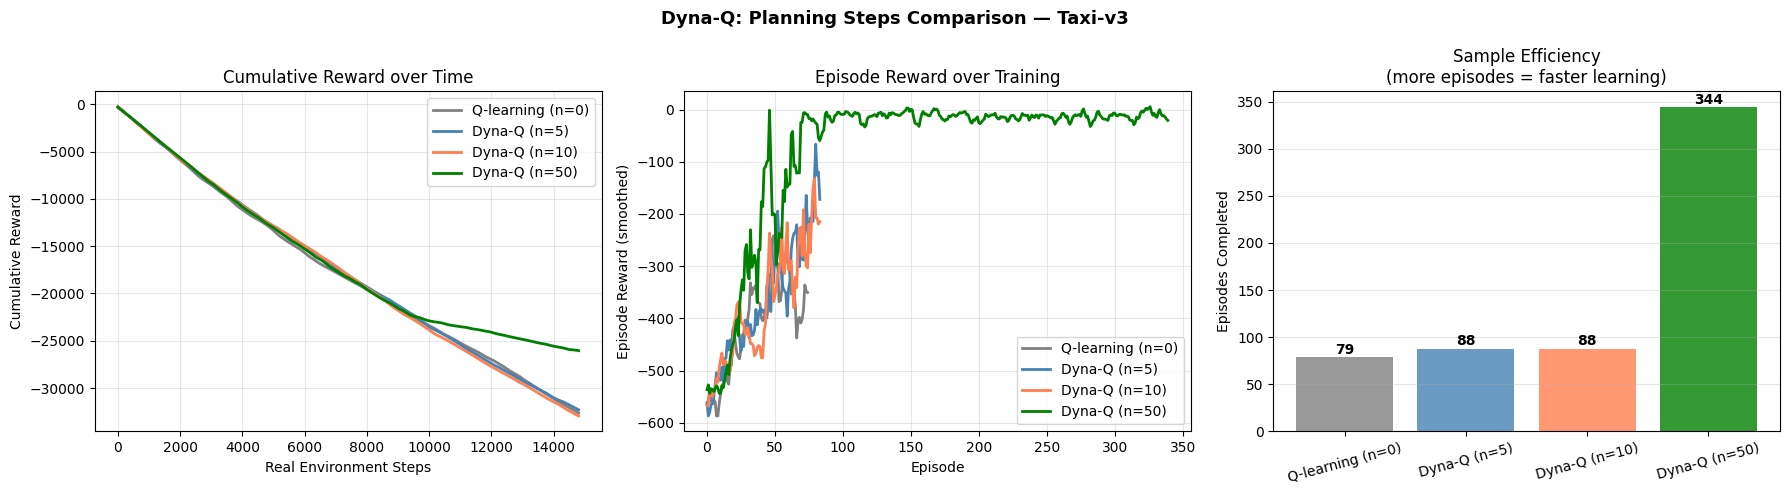


Episodes completed:
  n= 0 : 79 episodes | best episode reward: -32
  n= 5 : 88 episodes | best episode reward: -13
  n=10 : 88 episodes | best episode reward: 11
  n=50 : 344 episodes | best episode reward: 15


In [10]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
ALPHA   = 0.1
GAMMA   = 0.95
EPSILON = 0.3
N_STEPS = 15000

def smooth(data, window=50):
    """Simple moving average for plotting."""
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window)/window, mode='valid')


def run_comparison(n_steps=N_STEPS, seed=SEED):
    planning_variants = [0, 5, 10, 50]
    results = {}

    for n in planning_variants:
        print(f'Running n_planning={n}...')
        rews, eps, ep_rews = run_dyna_q(n_planning=n,
                                         n_steps=n_steps,
                                         seed=seed)
        results[n] = {
            'rewards'        : rews,
            'episodes'       : eps,
            'episode_rewards': ep_rews
        }
        print(f'  episodes completed : {eps}')
        print(f'  mean reward        : {np.mean(rews):.3f}')

    return results


# ── Run comparison ────────────────────────────────────────────────────────────
print('Running comparison (this takes 2-3 minutes)...')
results = run_comparison(n_steps=N_STEPS)


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dyna-Q: Planning Steps Comparison — Taxi-v3',
             fontsize=13, fontweight='bold')

colors = {0: 'gray', 5: 'steelblue', 10: 'coral', 50: 'green'}
labels = {0: 'Q-learning (n=0)', 5: 'Dyna-Q (n=5)',
          10: 'Dyna-Q (n=10)',   50: 'Dyna-Q (n=50)'}

# ── Left: cumulative reward ───────────────────────────────────────────────────
ax1 = axes[0]
for n, res in results.items():
    cum = np.cumsum(res['rewards'])
    sm  = smooth(cum, window=200)
    ax1.plot(np.arange(len(sm)), sm,
             color=colors[n], label=labels[n], lw=2)
ax1.set_xlabel('Real Environment Steps')
ax1.set_ylabel('Cumulative Reward')
ax1.set_title('Cumulative Reward over Time')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Middle: episode reward over episodes ──────────────────────────────────────
ax2 = axes[1]
for n, res in results.items():
    ep_r = res['episode_rewards']
    if len(ep_r) > 5:
        sm_ep = smooth(ep_r, window=5)
        ax2.plot(np.arange(len(sm_ep)), sm_ep,
                 color=colors[n], label=labels[n], lw=2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Episode Reward (smoothed)')
ax2.set_title('Episode Reward over Training')
ax2.legend()
ax2.grid(alpha=0.3)

# ── Right: episodes completed bar chart ───────────────────────────────────────
ax3 = axes[2]
ns        = list(results.keys())
ep_counts = [results[n]['episodes'] for n in ns]
bars = ax3.bar([labels[n] for n in ns], ep_counts,
               color=[colors[n] for n in ns], alpha=0.8)
for bar, val in zip(bars, ep_counts):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold')
ax3.set_ylabel('Episodes Completed')
ax3.set_title('Sample Efficiency\n(more episodes = faster learning)')
ax3.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('dyna_q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print('Episodes completed:')
for n in [0, 5, 10, 50]:
    ep_r = results[n]['episode_rewards']
    best = max(ep_r) if ep_r else 0
    print(f'  n={n:2d} : {results[n]["episodes"]} episodes | '
          f'best episode reward: {best:.0f}')

# Dyna-Q+ with Exploration Bonus

In [12]:
KAPPA = 0.01    # exploration bonus weight κ

def run_dyna_q_plus(n_planning, n_steps=N_STEPS, seed=SEED):
    """
    Dyna-Q+ adds an exploration bonus to planning updates.

    For state-action pairs not visited in τ steps, the simulated
    reward is augmented: r' = r + κ√τ

    This encourages the agent to revisit parts of the model
    it has not checked recently — critical when the environment changes.

    Extra data structure:
        time_since[(s,a)] = number of steps since (s,a) was last tried
    """
    env  = gym.make('Taxi-v3')
    obs, _ = env.reset(seed=seed)

    Q          = make_q_table(n_states, n_actions)
    M          = make_model()
    time_since = {}     # (s,a) → steps since last real visit

    rewards_per_step  = []
    episode_rewards   = []
    episodes_done     = 0
    current_ep_reward = 0

    for step in range(n_steps):
        state  = obs
        action = select_action(Q, state, EPSILON)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # ── Direct RL update ──────────────────────────────────────────────
        q_update(Q, state, action, reward, next_obs, done)

        # ── Update model and time trackers ────────────────────────────────
        if not done:
            update_model(M, state, action, reward, next_obs)

        # Mark this (s,a) as just visited
        time_since[(state, action)] = 0

        # Increment all other tracked pairs by 1
        for key in time_since:
            if key != (state, action):
                time_since[key] += 1

        # ── Planning with exploration bonus ───────────────────────────────
        if len(M) > 0:
            visited = list(M.keys())
            for _ in range(n_planning):
                s, a = random.choice(visited)
                r, ns = M[(s, a)]

                # Get time since last visit, default 0 if never tracked
                tau = time_since.get((s, a), 0)

                # BUG: exploration bonus uses tau directly instead of sqrt(tau)
                # Large tau values will create huge artificial rewards
                # completely overwhelming the real reward signal
                # bonus     = KAPPA * tau
                bonus = KAPPA * np.sqrt(tau)    # matches S&B Section 8.3
                r_plus    = r + bonus
                q_update(Q, s, a, r_plus, ns, done=False)

        # ── Logging ───────────────────────────────────────────────────────
        current_ep_reward += reward
        rewards_per_step.append(reward)

        if done:
            episodes_done += 1
            episode_rewards.append(current_ep_reward)
            obs, _ = env.reset()
            current_ep_reward = 0
        else:
            obs = next_obs

    env.close()
    return rewards_per_step, episodes_done, episode_rewards


# ── Sanity check: verify bonus calculation ────────────────────────────────────
print('Exploration bonus check:')
print(f'  kappa = {KAPPA}')
print()

test_taus = [0, 10, 100, 1000, 10000]
print(f'  {"tau":>8} | {"buggy bonus (κ*τ)":>20} | {"correct bonus (κ*√τ)":>20}')
print(f'  {"-"*55}')
for tau in test_taus:
    buggy   = KAPPA * tau
    correct = KAPPA * np.sqrt(tau)
    print(f'  {tau:>8} | {buggy:>20.4f} | {correct:>20.4f}')

print()
print('If tau=10000, buggy bonus=100.0 completely drowns real rewards')
print('Correct bonus=1.0 stays proportional and manageable')

Exploration bonus check:
  kappa = 0.01

       tau |    buggy bonus (κ*τ) | correct bonus (κ*√τ)
  -------------------------------------------------------
         0 |               0.0000 |               0.0000
        10 |               0.1000 |               0.0316
       100 |               1.0000 |               0.1000
      1000 |              10.0000 |               0.3162
     10000 |             100.0000 |               1.0000

If tau=10000, buggy bonus=100.0 completely drowns real rewards
Correct bonus=1.0 stays proportional and manageable


In [13]:
# ── Quick functional test ─────────────────────────────────────────────────────
print('Functional test — Dyna-Q+ bonus working inside function:')

rews_plus, eps_plus, ep_rews_plus = run_dyna_q_plus(
    n_planning=50, n_steps=500, seed=SEED
)

print(f'Steps run          : {len(rews_plus)}')
print(f'Episodes completed : {eps_plus}')
print(f'Mean reward        : {np.mean(rews_plus):.3f}')
print(f'Max reward seen    : {max(rews_plus)}')
print()
print('If max reward is 20 the agent found a successful dropoff.')
print('If mean reward is worse than -10, bonus is still too large.')

Functional test — Dyna-Q+ bonus working inside function:
Steps run          : 500
Episodes completed : 2
Mean reward        : -2.746
Max reward seen    : -1

If max reward is 20 the agent found a successful dropoff.
If mean reward is worse than -10, bonus is still too large.


# Dynamic Environment Change: Dyna-Q vs Dyna-Q+

In [15]:
CHANGE_STEP = 5000    # environment changes halfway through training

def run_dyna_q_changing_env(use_plus=False, n_planning=50,
                             n_steps=10000, seed=SEED):
    """
    Simulates a changing environment by flipping the reward structure
    at CHANGE_STEP real steps.

    Before change: normal Taxi-v3 rewards
    After change : successful dropoff reward flipped to -20 (penalty)
                   and illegal moves give +10 instead of -10

    This tests whether the agent can detect and adapt to the change.
    Dyna-Q  : keeps using stale model → slow to adapt
    Dyna-Q+ : exploration bonus forces revisiting → adapts faster
    """
    env = gym.make('Taxi-v3')
    obs, _ = env.reset(seed=seed)

    Q          = make_q_table(n_states, n_actions)
    M          = make_model()
    time_since = {}

    rewards_per_step  = []
    episode_rewards   = []
    episodes_done     = 0
    current_ep_reward = 0
    env_changed       = False

    for step in range(n_steps):
        state  = obs
        action = select_action(Q, state, EPSILON)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # ── Apply environment change at CHANGE_STEP ───────────────────────
        if step >= CHANGE_STEP:
            if not env_changed:
                print(f'  Environment changed at step {step}')
                env_changed = True
            # After change: flip reward signs to simulate changed dynamics
            if reward == 20:
                reward = -20
            elif reward == -10:
                reward = 10

        # ── Direct RL update ──────────────────────────────────────────────
        q_update(Q, state, action, reward, next_obs, done)

        # ── Update model ──────────────────────────────────────────────────
        if not done:
            update_model(M, state, action, reward, next_obs)

        # ── Time tracking ─────────────────────────────────────────────────
        time_since[(state, action)] = 0
        for key in time_since:
            if key != (state, action):
                time_since[key] += 1

        # ── Planning ──────────────────────────────────────────────────────
        if len(M) > 0:
            visited = list(M.keys())
            for _ in range(n_planning):
                s, a   = random.choice(visited)
                r, ns  = M[(s, a)]

                # if use_plus:
                #     tau    = time_since.get((s, a), 0)
                #     bonus  = KAPPA * np.sqrt(tau)
                #     r      = r + bonus   # BUG: modifies r in-place
                #                          # corrupts the model lookup variable
                #                          # next planning iteration that picks
                #                          # the same (s,a) sees inflated reward

                # q_update(Q, s, a, r, ns, done=False)
                if use_plus:
                    tau    = time_since.get((s, a), 0)
                    r_plus = r + KAPPA * np.sqrt(tau)
                else:
                    r_plus = r

                q_update(Q, s, a, r_plus, ns, done=False)
        # ── Logging ───────────────────────────────────────────────────────
        current_ep_reward += reward
        rewards_per_step.append(reward)

        if done:
            episodes_done += 1
            episode_rewards.append(current_ep_reward)
            obs, _ = env.reset()
            current_ep_reward = 0
        else:
            obs = next_obs

    env.close()
    return rewards_per_step, episodes_done, episode_rewards


# ── Sanity check ──────────────────────────────────────────────────────────────
print('Running Dyna-Q+ with changing env (sanity check, 500 steps)...')
rews_c, eps_c, ep_c = run_dyna_q_changing_env(
    use_plus=True, n_planning=50, n_steps=500, seed=SEED
)
print(f'Steps     : {len(rews_c)}')
print(f'Episodes  : {eps_c}')
print(f'Mean reward before change : '
      f'{np.mean(rews_c[:min(500,CHANGE_STEP)]):.3f}')
print()
print('Mean reward should be around -2 to -4')
print('No crash means the variable shadowing bug may be silent here')
print('It becomes visible when same (s,a) is sampled twice in one')
print('planning loop — reward keeps growing with each re-sample')

Running Dyna-Q+ with changing env (sanity check, 500 steps)...
Steps     : 500
Episodes  : 2
Mean reward before change : -2.872

Mean reward should be around -2 to -4
No crash means the variable shadowing bug may be silent here
It becomes visible when same (s,a) is sampled twice in one
planning loop — reward keeps growing with each re-sample


Running Dyna-Q  (no bonus)...
  Environment changed at step 5000
Running Dyna-Q+ (with bonus)...
  Environment changed at step 5000


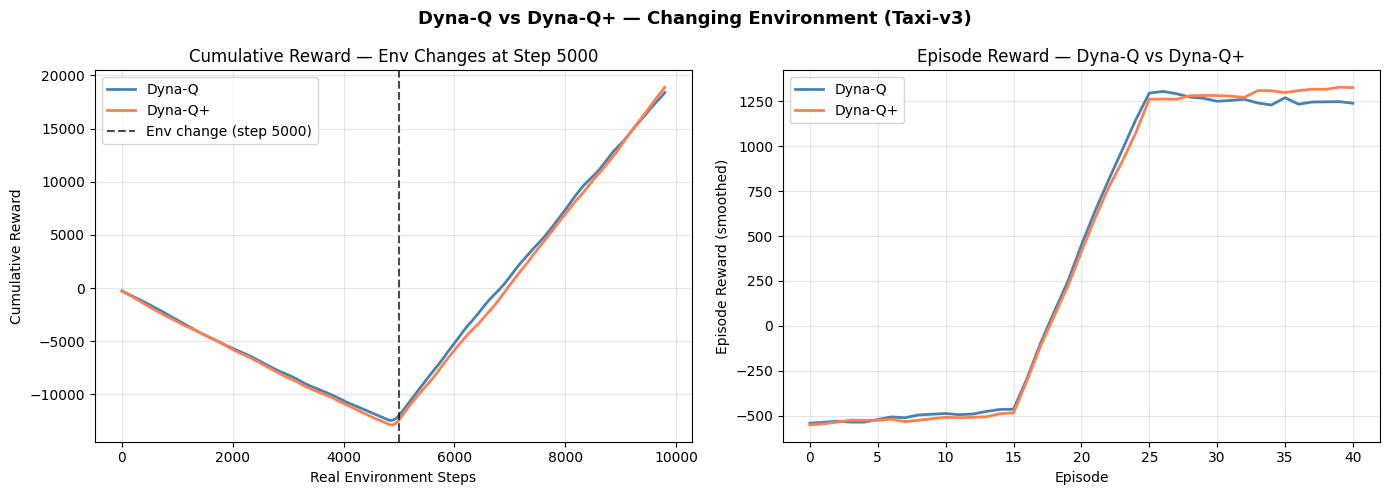


=== Summary ===
Dyna-Q  episodes : 50  | mean reward: 1.911
Dyna-Q+ episodes : 50 | mean reward: 1.962

Mean reward BEFORE change:
  Dyna-Q  : -2.514
  Dyna-Q+ : -2.602

Mean reward AFTER change:
  Dyna-Q  : 6.335
  Dyna-Q+ : 6.526

Dyna-Q+ should recover faster after the change
visible as a smaller drop in mean reward after step 5000


In [16]:
print('Running Dyna-Q  (no bonus)...')
rews_dq, eps_dq, ep_dq = run_dyna_q_changing_env(
    use_plus=False, n_planning=50, n_steps=10000, seed=SEED
)

print('Running Dyna-Q+ (with bonus)...')
rews_dqp, eps_dqp, ep_dqp = run_dyna_q_changing_env(
    use_plus=True, n_planning=50, n_steps=10000, seed=SEED
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dyna-Q vs Dyna-Q+ — Changing Environment (Taxi-v3)',
             fontsize=13, fontweight='bold')

# ── Left: cumulative reward ───────────────────────────────────────────────────
ax1 = axes[0]
for rews, label, color in [
    (rews_dq,  'Dyna-Q',  'steelblue'),
    (rews_dqp, 'Dyna-Q+', 'coral')
]:
    cum = np.cumsum(rews)
    sm  = smooth(cum, window=200)
    ax1.plot(np.arange(len(sm)), sm, label=label, color=color, lw=2)

ax1.axvline(CHANGE_STEP, color='black', ls='--',
            alpha=0.7, label=f'Env change (step {CHANGE_STEP})')
ax1.set_xlabel('Real Environment Steps')
ax1.set_ylabel('Cumulative Reward')
ax1.set_title('Cumulative Reward — Env Changes at Step 5000')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Right: episode reward over time ──────────────────────────────────────────
ax2 = axes[1]
for ep_rews, label, color in [
    (ep_dq,  'Dyna-Q',  'steelblue'),
    (ep_dqp, 'Dyna-Q+', 'coral')
]:
    if len(ep_rews) > 5:
        sm_ep = smooth(ep_rews, window=10)
        ax2.plot(np.arange(len(sm_ep)), sm_ep,
                 label=label, color=color, lw=2)

ax2.set_xlabel('Episode')
ax2.set_ylabel('Episode Reward (smoothed)')
ax2.set_title('Episode Reward — Dyna-Q vs Dyna-Q+')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dyna_q_plus_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print('=== Summary ===')
print(f'Dyna-Q  episodes : {eps_dq}  | '
      f'mean reward: {np.mean(rews_dq):.3f}')
print(f'Dyna-Q+ episodes : {eps_dqp} | '
      f'mean reward: {np.mean(rews_dqp):.3f}')
print()

# Split before and after change
before_dq  = np.mean(rews_dq[:CHANGE_STEP])
after_dq   = np.mean(rews_dq[CHANGE_STEP:])
before_dqp = np.mean(rews_dqp[:CHANGE_STEP])
after_dqp  = np.mean(rews_dqp[CHANGE_STEP:])

print(f'Mean reward BEFORE change:')
print(f'  Dyna-Q  : {before_dq:.3f}')
print(f'  Dyna-Q+ : {before_dqp:.3f}')
print()
print(f'Mean reward AFTER change:')
print(f'  Dyna-Q  : {after_dq:.3f}')
print(f'  Dyna-Q+ : {after_dqp:.3f}')
print()
print('Dyna-Q+ should recover faster after the change')
print('visible as a smaller drop in mean reward after step 5000')

In [24]:
THETA = 0.01

def run_prioritized_sweeping(n_planning=50, n_steps=N_STEPS, seed=SEED):
    env = gym.make('Taxi-v3')
    obs, _ = env.reset(seed=seed)

    Q            = make_q_table(n_states, n_actions)
    M            = make_model()
    pqueue       = []
    in_queue     = set()
    predecessors = defaultdict(set)

    rewards_per_step  = []
    episode_rewards   = []
    episodes_done     = 0
    current_ep_reward = 0

    for step in range(n_steps):
        state  = obs
        action = select_action(Q, state, EPSILON)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # ── Update model, predecessors, queue ─────────────────────────────
        if not done:
            update_model(M, state, action, reward, next_obs)
            predecessors[next_obs].add((state, action))

            td_error = abs(reward + GAMMA * np.max(Q[next_obs])
                           - Q[state, action])
            if td_error > THETA and (state, action) not in in_queue:
                heapq.heappush(pqueue, (-td_error, state, action))
                in_queue.add((state, action))
        else:
            td_error = abs(reward - Q[state, action])

        # ── Prioritized planning ──────────────────────────────────────────
        for _ in range(n_planning):
            if len(pqueue) == 0:
                break

            _, s, a = heapq.heappop(pqueue)
            in_queue.discard((s, a))

            r, ns = M[(s, a)]
            q_update(Q, s, a, r, ns, done=False)

            for (ps, pa) in predecessors[s]:
                if (ps, pa) in M:
                    pr, pns = M[(ps, pa)]
                    p_td = abs(pr + GAMMA * np.max(Q[pns]) - Q[ps, pa])
                    if p_td > THETA and (ps, pa) not in in_queue:
                        heapq.heappush(pqueue, (-p_td, ps, pa))
                        in_queue.add((ps, pa))

        # ── Direct RL update ──────────────────────────────────────────────
        q_update(Q, state, action, reward, next_obs, done)

        # ── Logging ───────────────────────────────────────────────────────
        current_ep_reward += reward
        rewards_per_step.append(reward)

        if done:
            episodes_done += 1
            episode_rewards.append(current_ep_reward)
            obs, _ = env.reset()
            current_ep_reward = 0
        else:
            obs = next_obs

    env.close()
    return rewards_per_step, episodes_done, episode_rewards
# ── Sanity check ──────────────────────────────────────────────────────────────
print('Heap behavior check:')
test_heap = []
heapq.heappush(test_heap, (-10.0, 5, 2))
heapq.heappush(test_heap, (-3.0,  1, 4))
heapq.heappush(test_heap, (-7.0,  9, 0))

print('Items pushed: priority=10 (s=5,a=2), priority=3 (s=1,a=4), '
      'priority=7 (s=9,a=0)')
print('Expected pop order: highest priority first (10, 7, 3)')
print()

while test_heap:
    val, s, a = heapq.heappop(test_heap)
    print(f'  popped: raw_val={val}, s={s}, a={a}  '
          f'← real priority={-val}')

# ── Functional test ───────────────────────────────────────────────────────────
print()
print('Running prioritized sweeping (500 steps)...')
rews_ps, eps_ps, ep_ps = run_prioritized_sweeping(
    n_planning=50, n_steps=500, seed=SEED
)
print(f'Steps       : {len(rews_ps)}')
print(f'Episodes    : {eps_ps}')
print(f'Mean reward : {np.mean(rews_ps):.3f}')
print('Mean reward should be around -2 to -4')

Heap behavior check:
Items pushed: priority=10 (s=5,a=2), priority=3 (s=1,a=4), priority=7 (s=9,a=0)
Expected pop order: highest priority first (10, 7, 3)

  popped: raw_val=-10.0, s=5, a=2  ← real priority=10.0
  popped: raw_val=-7.0, s=9, a=0  ← real priority=7.0
  popped: raw_val=-3.0, s=1, a=4  ← real priority=3.0

Running prioritized sweeping (500 steps)...
Steps       : 500
Episodes    : 2
Mean reward : -2.764
Mean reward should be around -2 to -4


Running Dyna-Q uniform planning (n=50)...
Running prioritized sweeping (n=50)...


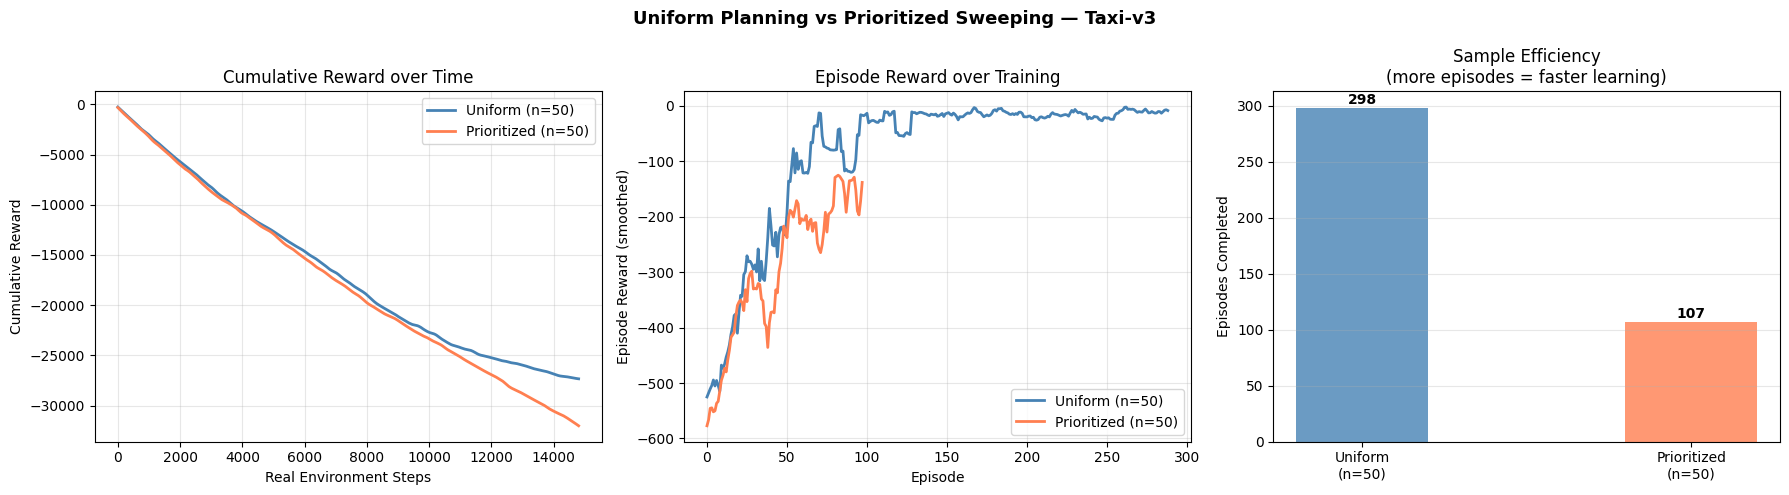


=== Final Summary ===
Uniform planning   : 298 episodes | mean reward: -1.826 | best ep: 14
Prioritized sweep  : 107 episodes | mean reward: -2.147 | best ep: 13

Episode ratio      : 0.36x (prioritized / uniform)
Mean reward ratio  : 1.18x

Prioritized sweeping should complete more episodes
by focusing planning where Q-values are most wrong


In [25]:
print('Running Dyna-Q uniform planning (n=50)...')
rews_uniform, eps_uniform, ep_uniform = run_dyna_q(
    n_planning=50, n_steps=N_STEPS, seed=SEED
)

print('Running prioritized sweeping (n=50)...')
rews_ps, eps_ps, ep_ps = run_prioritized_sweeping(
    n_planning=50, n_steps=N_STEPS, seed=SEED
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Uniform Planning vs Prioritized Sweeping — Taxi-v3',
             fontsize=13, fontweight='bold')

colors = {'uniform': 'steelblue', 'prioritized': 'coral'}

# ── Left: cumulative reward ───────────────────────────────────────────────────
ax1 = axes[0]
for rews, label, color in [
    (rews_uniform, 'Uniform (n=50)',      'steelblue'),
    (rews_ps,      'Prioritized (n=50)',  'coral')
]:
    cum = np.cumsum(rews)
    sm  = smooth(cum, window=200)
    ax1.plot(np.arange(len(sm)), sm, label=label, color=color, lw=2)

ax1.set_xlabel('Real Environment Steps')
ax1.set_ylabel('Cumulative Reward')
ax1.set_title('Cumulative Reward over Time')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Middle: episode reward over episodes ──────────────────────────────────────
ax2 = axes[1]
for ep_rews, label, color in [
    (ep_uniform, 'Uniform (n=50)',     'steelblue'),
    (ep_ps,      'Prioritized (n=50)', 'coral')
]:
    if len(ep_rews) > 5:
        sm_ep = smooth(ep_rews, window=10)
        ax2.plot(np.arange(len(sm_ep)), sm_ep,
                 label=label, color=color, lw=2)

ax2.set_xlabel('Episode')
ax2.set_ylabel('Episode Reward (smoothed)')
ax2.set_title('Episode Reward over Training')
ax2.legend()
ax2.grid(alpha=0.3)

# ── Right: episodes completed bar chart ───────────────────────────────────────
ax3 = axes[2]
labels    = ['Uniform\n(n=50)', 'Prioritized\n(n=50)']
ep_counts = [eps_uniform, eps_ps]
bar_colors = ['steelblue', 'coral']
bars = ax3.bar(labels, ep_counts, color=bar_colors, alpha=0.8, width=0.4)

for bar, val in zip(bars, ep_counts):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold')

ax3.set_ylabel('Episodes Completed')
ax3.set_title('Sample Efficiency\n(more episodes = faster learning)')
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('prioritized_vs_uniform.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print('=== Final Summary ===')
print(f'Uniform planning   : {eps_uniform} episodes | '
      f'mean reward: {np.mean(rews_uniform):.3f} | '
      f'best ep: {max(ep_uniform):.0f}')
print(f'Prioritized sweep  : {eps_ps} episodes | '
      f'mean reward: {np.mean(rews_ps):.3f} | '
      f'best ep: {max(ep_ps):.0f}')
print()
print(f'Episode ratio      : {eps_ps/eps_uniform:.2f}x '
      f'(prioritized / uniform)')
print(f'Mean reward ratio  : {np.mean(rews_ps)/np.mean(rews_uniform):.2f}x')
print()
print('Prioritized sweeping should complete more episodes')
print('by focusing planning where Q-values are most wrong')